In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Data cleaning

In [29]:
df = pd.read_csv('/energy_dataset.csv')

In [30]:
df.head()

,time,generation biomass,generation fossil brown coal/lignite,generation fossil coal-derived gas,generation fossil gas,generation fossil hard coal,generation fossil oil,generation fossil oil shale,generation fossil peat,generation geothermal,...,generation waste,generation wind offshore,generation wind onshore,forecast solar day ahead,forecast wind offshore eday ahead,forecast wind onshore day ahead,total load forecast,total load actual,price day ahead,price actual
0,2015-01-01 00:00:00+01:00,447.0,329.0,0.0,4844.0,4821.0,162.0,0.0,0.0,0.0,...,196.0,0.0,6378.0,17.0,NaN,6436.0,26118.0,25385.0,50.10,65.41
1,2015-01-01 01:00:00+01:00,449.0,328.0,0.0,5196.0,4755.0,158.0,0.0,0.0,0.0,...,195.0,0.0,5890.0,16.0,NaN,5856.0,24934.0,24382.0,48.10,64.92
2,2015-01-01 02:00:00+01:00,448.0,323.0,0.0,4857.0,4581.0,157.0,0.0,0.0,0.0,...,196.0,0.0,5461.0,8.0,NaN,5454.0,23515.0,22734.0,47.33,64.48
3,2015-01-01 03:00:00+01:00,438.0,254.0,0.0,4314.0,4131.0,160.0,0.0,0.0,0.0,...,191.0,0.0,5238.0,2.0,NaN,5151.0,22642.0,21286.0,42.27,59.32
4,2015-01-01 04:00:00+01:00,428.0,187.0,0.0,4130.0,3840.0,156.0,0.0,0.0,0.0,...,189.0,0.0,4935.0,9.0,NaN,4861.0,21785.0,20264.0,38.41,56.04


In [31]:
df.shape

(35064, 29)

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 29 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   time                                         35064 non-null  object 
 1   generation biomass                           35045 non-null  float64
 2   generation fossil brown coal/lignite         35046 non-null  float64
 3   generation fossil coal-derived gas           35046 non-null  float64
 4   generation fossil gas                        35046 non-null  float64
 5   generation fossil hard coal                  35046 non-null  float64
 6   generation fossil oil                        35045 non-null  float64
 7   generation fossil oil shale                  35046 non-null  float64
 8   generation fossil peat                       35046 non-null  float64
 9   generation geothermal                        35046 non-null  float64
 10

In [33]:
#I remove empty colums
df = df.drop(columns=['generation hydro pumped storage aggregated',
                       'forecast wind offshore eday ahead'])

#I convert 'time' to real datetime then I set it as the index
df['time'] = pd.to_datetime(df['time'], utc=True)
df = df.set_index('time')

In [37]:
#I check that Time is now the index. Also I make sure that the two empty columns disappeared
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 35064 entries, 2014-12-31 23:00:00+00:00 to 2018-12-31 22:00:00+00:00
Data columns (total 26 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   generation biomass                           35045 non-null  float64
 1   generation fossil brown coal/lignite         35046 non-null  float64
 2   generation fossil coal-derived gas           35046 non-null  float64
 3   generation fossil gas                        35046 non-null  float64
 4   generation fossil hard coal                  35046 non-null  float64
 5   generation fossil oil                        35045 non-null  float64
 6   generation fossil oil shale                  35046 non-null  float64
 7   generation fossil peat                       35046 non-null  float64
 8   generation geothermal                        35046 non-null  float64
 9   generation hydro pumped s

(35064, 26)

In [38]:
#I count the empty data
df.isna().sum()

,0
generation biomass,19
generation fossil brown coal/lignite,18
generation fossil coal-derived gas,18
generation fossil gas,18
generation fossil hard coal,18
generation fossil oil,19
generation fossil oil shale,18
generation fossil peat,18
generation geothermal,18
generation hydro pumped storage consumption,19


In [39]:
#I prefer interpolating because only a very few data lacks to the df
df = df.interpolate(method='time')

In [40]:
#Now I make sure that there is no missing data anymore
df.isna().sum()

,0
generation biomass,0
generation fossil brown coal/lignite,0
generation fossil coal-derived gas,0
generation fossil gas,0
generation fossil hard coal,0
generation fossil oil,0
generation fossil oil shale,0
generation fossil peat,0
generation geothermal,0
generation hydro pumped storage consumption,0


# First overview of energy price

Let's try to identify paterns and set hypothesis.
First, I begin with the 4 years. Then, I move to narrower timescales.

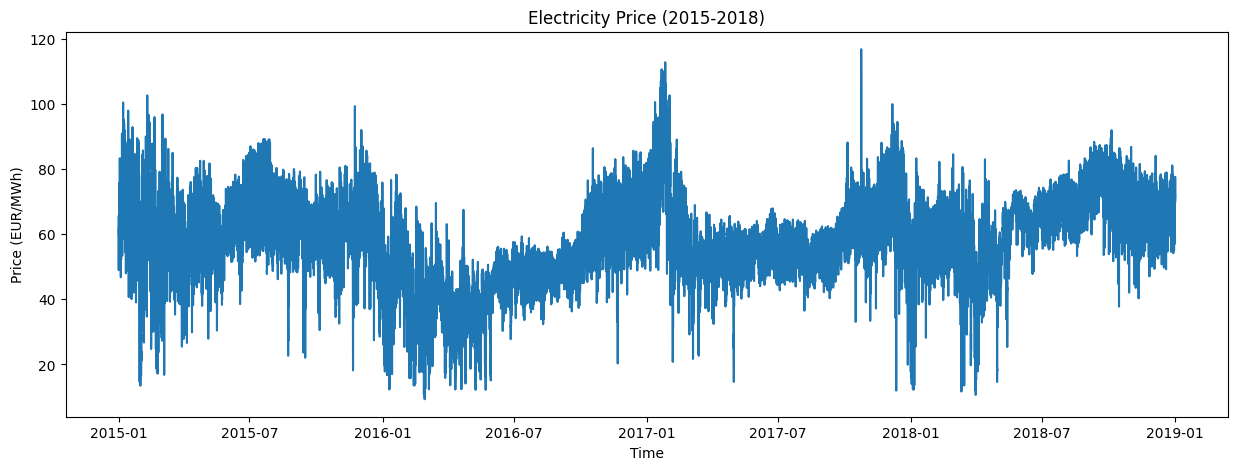

In [41]:
plt.figure(figsize=(15, 5))
plt.plot(df.index, df['price actual'])
plt.title('Electricity Price (2015-2018)')
plt.xlabel('Time')
plt.ylabel('Price (EUR/MWh)')
plt.show()

I observe a noisy signal that is not easy to exploit. However, the picks are often reached during winter. It seems normal because of the big need of electricity during this season for heating and lights.

Let's now look what happens when focusing on a week. I arbitrarily put in parameter the very first week of June 2015.

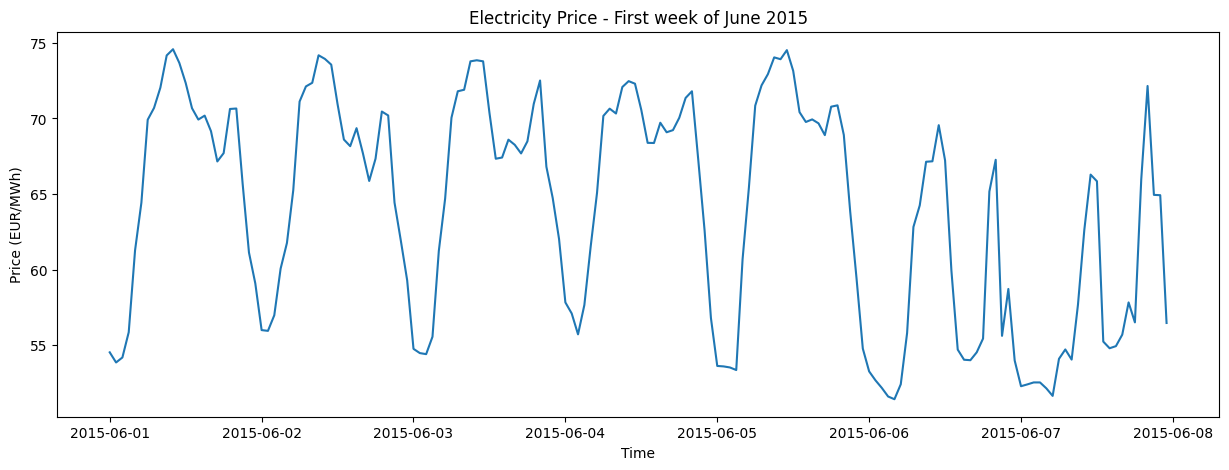

In [42]:
week = df.loc['2015-06-01':'2015-06-07']

plt.figure(figsize=(15, 5))
plt.plot(week.index, week['price actual'])
plt.title('Electricity Price - First week of June 2015')
plt.xlabel('Time')
plt.ylabel('Price (EUR/MWh)')
plt.show()

I notice repeating daily pattern: price low overnight, rising through the morning, often a dip around midday, rising again in early evening, then falling overnight again. This daily rhythm is the fingerprint of electricity demand (people wake up, go to work, cook dinner, sleep)

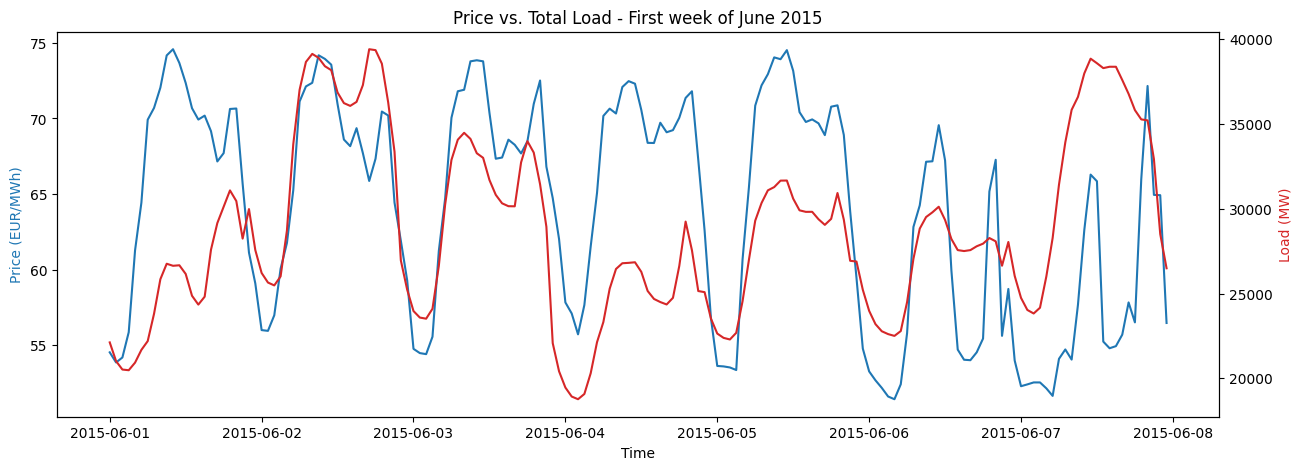

In [43]:
fig, ax1 = plt.subplots(figsize=(15, 5))

ax1.plot(week.index, week['price actual'], color='tab:blue', label='Price (EUR/MWh)')
ax1.set_xlabel('Time')
ax1.set_ylabel('Price (EUR/MWh)', color='tab:blue')

ax2 = ax1.twinx()
ax2.plot(week.index, week['total load actual'], color='tab:red', label='Load (MW)')
ax2.set_ylabel('Load (MW)', color='tab:red')

plt.title('Price vs. Total Load - First week of June 2015')
plt.show()

The price does not follow linearly the price. I see a corelation between both signals but I want to understand why the last day (June 7th) they are that unlincked whereas the second day (June 2nd) they were more corelated.
Therefore, I focus on the last day to try to understand what could have happened.

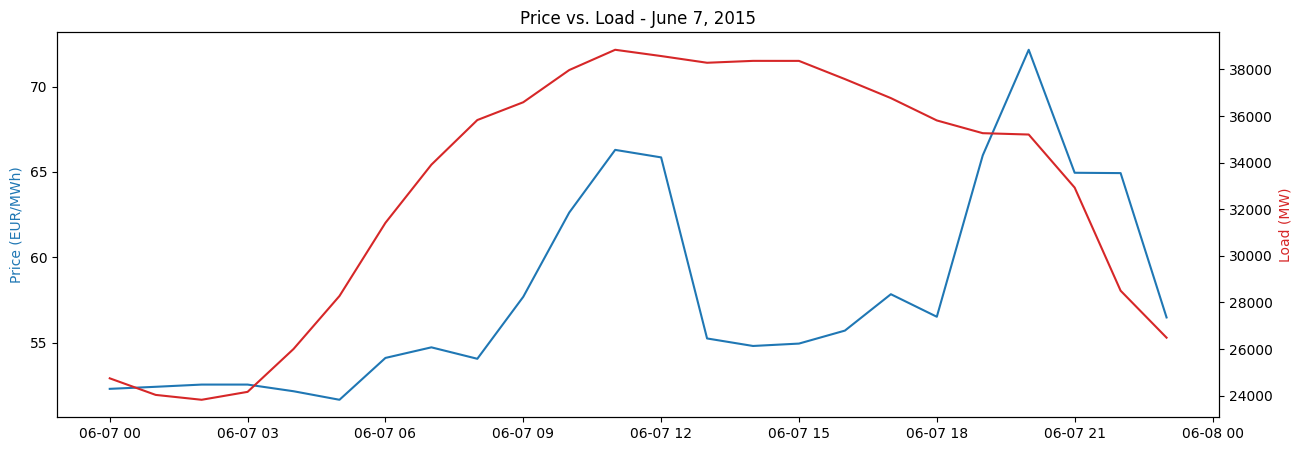

In [47]:
day1 = df.loc['2015-06-07']

fig, ax1 = plt.subplots(figsize=(15, 5))
ax1.plot(day1.index, day1['price actual'], color='tab:blue', label='Price')
ax1.set_ylabel('Price (EUR/MWh)', color='tab:blue')

ax2 = ax1.twinx()
ax2.plot(day1.index, day1['total load actual'], color='tab:red', label='Load')
ax2.set_ylabel('Load (MW)', color='tab:red')

plt.title('Price vs. Load - June 7, 2015')
plt.show()

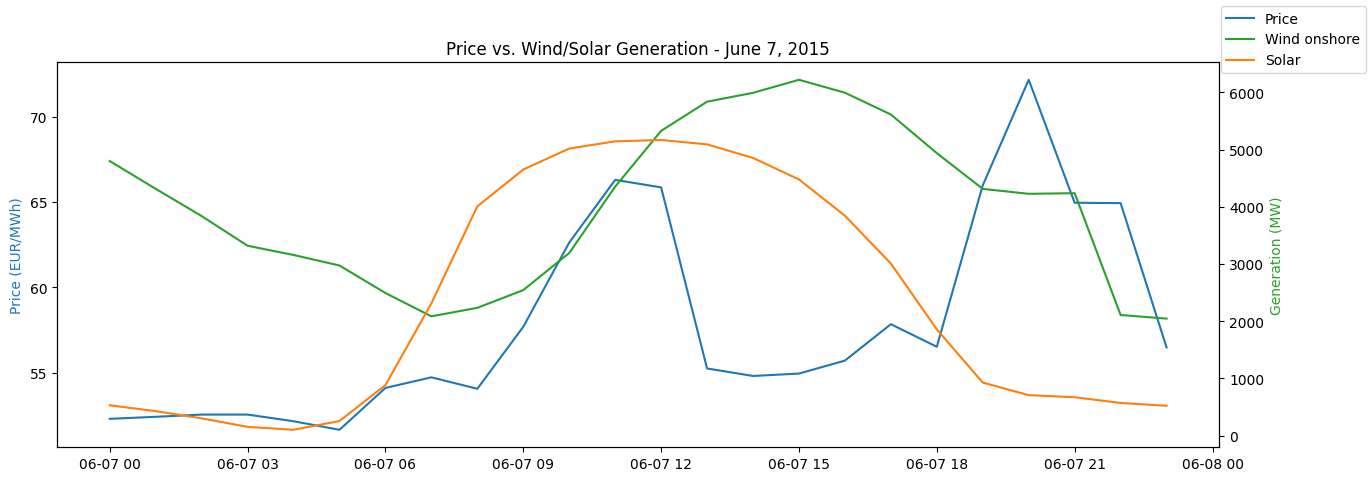

In [48]:
fig, ax1 = plt.subplots(figsize=(15, 5))
ax1.plot(day1.index, day1['price actual'], color='tab:blue', label='Price')
ax1.set_ylabel('Price (EUR/MWh)', color='tab:blue')

ax2 = ax1.twinx()
ax2.plot(day1.index, day1['generation wind onshore'], color='tab:green', label='Wind onshore')
ax2.plot(day1.index, day1['generation solar'], color='tab:orange', label='Solar')
ax2.set_ylabel('Generation (MW)', color='tab:green')

fig.legend(loc='upper right')
plt.title('Price vs. Wind/Solar Generation - June 7, 2015')
plt.show()

I notice that the wind onshore and the solar generation seemed important this day. This energy sources have a low marginal cost. It may be a first idea to explain why the price remained low on June 7th while the load was high.
However, this day taken alone does not help a lot to find the solution. I will therefore try to compare this plot to June 2nd and see if solar and wind onshore sources where also generating a lot. If not, The first hypothesis would be even more credible.